# Packages

In [2]:
import spatialdata as spd
from pathlib import Path

# Data

In [3]:
zarr_file = Path("/coh_labs/yunroseli/Jona/CAR-T/data/zarr/CellCharterClusters_c2l_annotated")
zdata = spd.read_zarr(zarr_file)

In [4]:
adataz = zdata.tables['segmentation_counts']

# Checking out datastruct

In [ ]:
adataz

AnnData object with n_obs × n_vars = 425859 × 19026
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', '_indices', '_scvi_batch', '_scvi_labels', 'batch_core', 'mt_counts', 'total_RNA_counts', 'treatment', 'n_counts', 'X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2', 'c2l_is_high_conf', 'c2l_winner', 'c2l_runnerup'
    var: 'n_counts'
    uns: '_scvi_uuid', 'spatialdata_attrs', 'cell2location_provenance', 'condition_colors', '_scvi_manager_uuid', 'spatial_neighbors', 'log1p'
    obsm: 'X_cc_1', 'X_cc_012', 'spatial', 'c2l_q95', 'X_cc_2', 'X_cc_01', 'c2l_q05', 'X_scVI', 'c2l_means'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [6]:
adataz.obs['c2l_winner'].unique()

array(['Unknown', 'CD8_T', 'Classical_Mono', 'Cancer_cell', 'Erythrocyte',
       'NK', 'NKT', 'B', 'Endothelial', 'M1_like_Mac', 'N2_like_Neu',
       'Treg', 'N1_like_Neu', 'M2_like_Mac', 'CD4_T', 'Fibroblast', 'cDC',
       'Nonclassical_Mono', 'pDC', 'Intermediate_Mac'], dtype=object)

In [9]:
adataz.obsm['c2l_q95'].head()

,B,CD4_T,CD8_T,Cancer_cell,Classical_Mono,Endothelial,Erythrocyte,Fibroblast,Intermediate_Mac,M1_like_Mac,M2_like_Mac,N1_like_Neu,N2_like_Neu,NK,NKT,Nonclassical_Mono,Treg,cDC,pDC
F07839_cellid_000000001-1,0.175893,0.123881,0.202598,0.136865,0.107566,0.082119,0.211539,0.090317,0.152785,0.146633,0.146722,0.184176,0.252440,0.188623,0.155840,0.111343,0.096887,0.135327,0.130463
F07839_cellid_000000002-1,0.155143,0.165055,0.390534,0.185244,0.122909,0.101051,0.371313,0.042787,0.113499,0.094085,0.053382,0.192520,0.080404,0.251822,0.215561,0.121227,0.114906,0.088054,0.149136
F07839_cellid_000000004-1,0.041440,0.018036,0.033090,0.011918,0.176132,0.031638,0.134936,0.099077,0.043755,0.152886,0.060522,0.132891,0.058312,0.023433,0.038378,0.110417,0.028099,0.039328,0.034519
F07839_cellid_000000005-1,0.076221,0.122054,0.220256,0.022345,0.311602,0.083513,0.135894,0.021562,0.064260,0.184529,0.038339,0.295147,0.069130,0.137438,0.104320,0.124396,0.167110,0.049963,0.051104
F07839_cellid_000000006-1,0.143083,0.124411,0.179736,0.132233,0.272196,0.106771,0.275114,0.038916,0.066823,0.106578,0.036066,0.299708,0.133860,0.128226,0.132649,0.241504,0.138274,0.101201,0.131061


In [10]:
adataz.obs.loc['F07839_cellid_000000001-1']

sample                                  F07839
cell_id              F07839_cellid_000000001-1
region              CyPSCA_1_1_cell_boundaries
TMA                                     F07839
mouse                               CyPSCA_1_1
tissue                              CyPSCA_1_1
condition                               CyPSCA
tumor_loc                                    1
replicate_num                                1
_indices                                     0
_scvi_batch                                  0
_scvi_labels                                 0
batch_core                  F07839__CyPSCA_1_1
mt_counts                                 59.0
total_RNA_counts                        2440.0
treatment                           CyPSCA_Tu1
n_counts                                2564.0
X_cc_1                                       0
X_cc_01                                      6
X_cc_012                                     2
X_cc_2                                       6
c2l_is_high_c

In [18]:
adataz.layers['counts']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 535580266 stored elements and shape (425859, 19026)>

In [ ]:
adataz.obs.

# Is data normalized?

In [16]:
import numpy as np

X = adataz.X
cnt = 100000
# If it's sparse, densify a sample
if hasattr(X, 'toarray'):
    sample = X[:cnt].toarray()
else:
    sample = np.array(X[:cnt])

print("Min:", sample.min())
print("Max:", sample.max())
print("Mean:", sample.mean())
print("Any values > 50:", (sample > 50).any())   # raw counts are often large integers
print("Any floats:", not np.all(sample == sample.astype(int)))  # normalized = non-integer


Min: 0.0
Max: 12.502342
Mean: 0.44593772
Any values > 50: False
Any floats: True


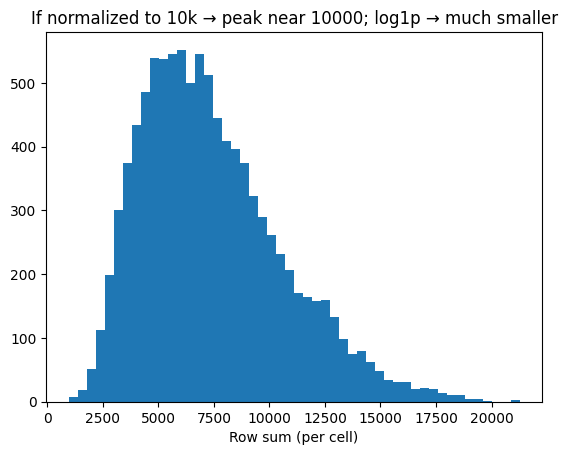

Median row sum: 6915.516


In [15]:
import matplotlib.pyplot as plt

row_sums = np.array(sample.sum(axis=1)).flatten()
plt.hist(row_sums, bins=50)
plt.xlabel("Row sum (per cell)")
plt.title("If normalized to 10k → peak near 10000; log1p → much smaller")
plt.show()
print("Median row sum:", np.median(row_sums))


In [17]:
print(adataz.uns.get('log1p'))       # should show {'base': None} if sc.pp.log1p was used
print(adataz.layers.keys())          # raw counts may be stored in layers['counts']


{'base': None}
KeysView(Layers with keys: counts)


# Looking around OBS

In [ ]:
adataz.obs.columns

Index(['sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition',
       'tumor_loc', 'replicate_num', '_indices', '_scvi_batch', '_scvi_labels',
       'batch_core', 'mt_counts', 'total_RNA_counts', 'treatment', 'n_counts',
       'X_cc_1', 'X_cc_01', 'X_cc_012', 'X_cc_2', 'c2l_is_high_conf',
       'c2l_winner', 'c2l_runnerup'],
      dtype='object')

In [21]:
adataz.obs['tissue'].unique()

['CyPSCA_1_1', 'CyPSCA_1_2', 'CyPSCA_2_4', 'CyT72_1_4', 'CyT72_2_3', ..., 'RTCyT72_2_4', 'CyT72_1_2', 'NoTx_2_4', 'RTCyPSCA_2_3', 'RTCyT72_1_1']
Length: 16
Categories (16, object): ['CyPSCA_1_1', 'CyPSCA_1_2', 'CyPSCA_2_4', 'CyT72_1_2', ..., 'RTCyPSCA_2_4', 'RTCyT72_1_1', 'RTCyT72_2_1', 'RTCyT72_2_4']